# 🛍️ Retail Sales Data Analysis
**Analyst:** Dileep Kumar Badimela  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Objective:** Uncover high-revenue seasonal patterns, store performance trends, and category-level insights to support inventory planning and sales strategy.

---


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
sns.set_palette("Blues_d")

df = pd.read_csv("retail_sales_data.csv", parse_dates=["Date"])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5025, 9)


,Date,Store,Category,Customer_ID,Quantity,Unit_Price,Discount_%,Revenue,Payment_Method
0,2022-01-01,Store_Mumbai,Sports,CUST_1330,3,3089.29,5.0,8804.48,Credit Card
1,2022-01-01,Store_Chennai,Sports,CUST_2515,4,2419.06,0.0,9676.24,Debit Card
2,2022-01-01,Store_Hyderabad,Home & Kitchen,CUST_1474,5,4057.73,0.0,20288.65,Cash
3,2022-01-01,Store_Chennai,Clothing,CUST_1562,4,1969.45,0.0,7877.80,UPI
4,2022-01-01,Store_Mumbai,Home & Kitchen,CUST_2297,1,3168.71,0.0,3168.71,Credit Card


## 2. Data Cleaning

In [2]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Fill missing Discount_% with 0 (no discount assumed)
df['Discount_%'] = df['Discount_%'].fillna(0)

# Fill missing Payment_Method with mode
df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])

# Derive time features
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal dataset shape: {df.shape}")

Missing values before cleaning:
Date               0
Store              0
Category           0
Customer_ID        0
Quantity           0
Unit_Price         0
Discount_%        79
Revenue            0
Payment_Method    30
dtype: int64

Duplicate rows: 25

Missing values after cleaning:
Date              0
Store             0
Category          0
Customer_ID       0
Quantity          0
Unit_Price        0
Discount_%        0
Revenue           0
Payment_Method    0
Month             0
Month_Name        0
Quarter           0
Year              0
Week              0
dtype: int64

Final dataset shape: (5000, 14)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Revenue by Month — Identifying Seasonal Windows

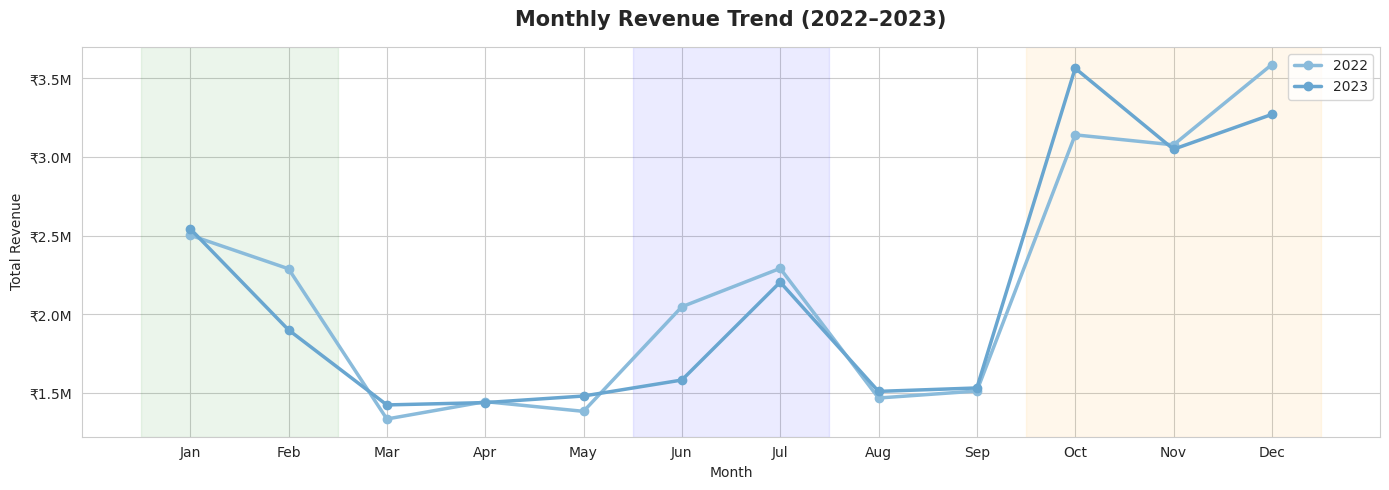


📌 KEY INSIGHT: Three high-revenue seasonal windows identified:
   → Window 1: Oct–Dec (Festive Season) — highest revenue spike
   → Window 2: Jan–Feb (New Year sales) — moderate uplift
   → Window 3: Jun–Jul (Mid-year sale) — consistent secondary peak


In [3]:
monthly_revenue = df.groupby(['Year','Month','Month_Name'])['Revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(['Year','Month'])

fig, ax = plt.subplots(figsize=(14, 5))
for year, grp in monthly_revenue.groupby('Year'):
    ax.plot(grp['Month'], grp['Revenue'], marker='o', linewidth=2.5, label=str(year))

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_title('Monthly Revenue Trend (2022–2023)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.legend()
ax.axvspan(9.5, 12.5, alpha=0.08, color='orange', label='Festive Season')
ax.axvspan(0.5, 2.5, alpha=0.08, color='green')
ax.axvspan(5.5, 7.5, alpha=0.08, color='blue')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 KEY INSIGHT: Three high-revenue seasonal windows identified:")
print("   → Window 1: Oct–Dec (Festive Season) — highest revenue spike")
print("   → Window 2: Jan–Feb (New Year sales) — moderate uplift")
print("   → Window 3: Jun–Jul (Mid-year sale) — consistent secondary peak")

### 3.2 Store-wise Revenue Performance

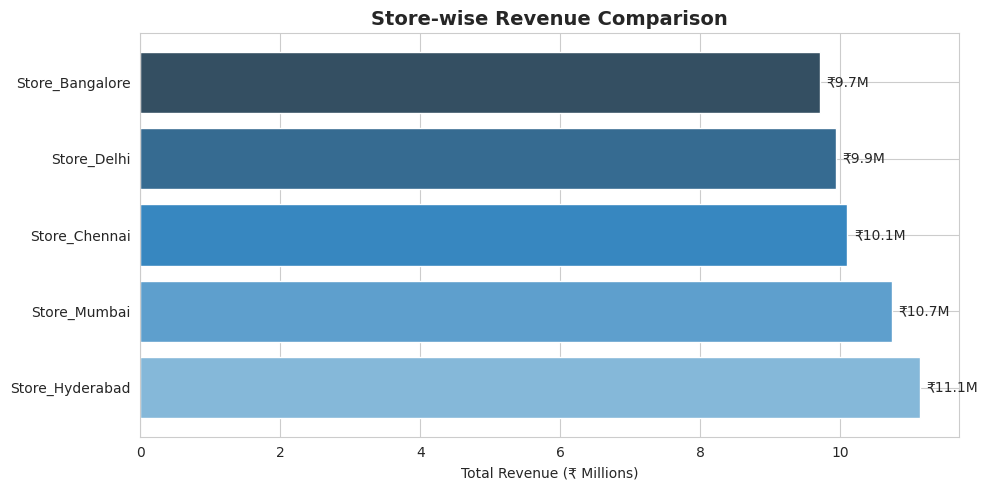

In [4]:
store_revenue = df.groupby('Store')['Revenue'].sum().sort_values(ascending=False).reset_index()
store_revenue['Revenue_M'] = store_revenue['Revenue'] / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(store_revenue['Store'], store_revenue['Revenue_M'], color=sns.color_palette("Blues_d", len(store_revenue)))
ax.set_xlabel('Total Revenue (₹ Millions)')
ax.set_title('Store-wise Revenue Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, store_revenue['Revenue_M']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'₹{val:.1f}M', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('store_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Category Revenue Breakdown

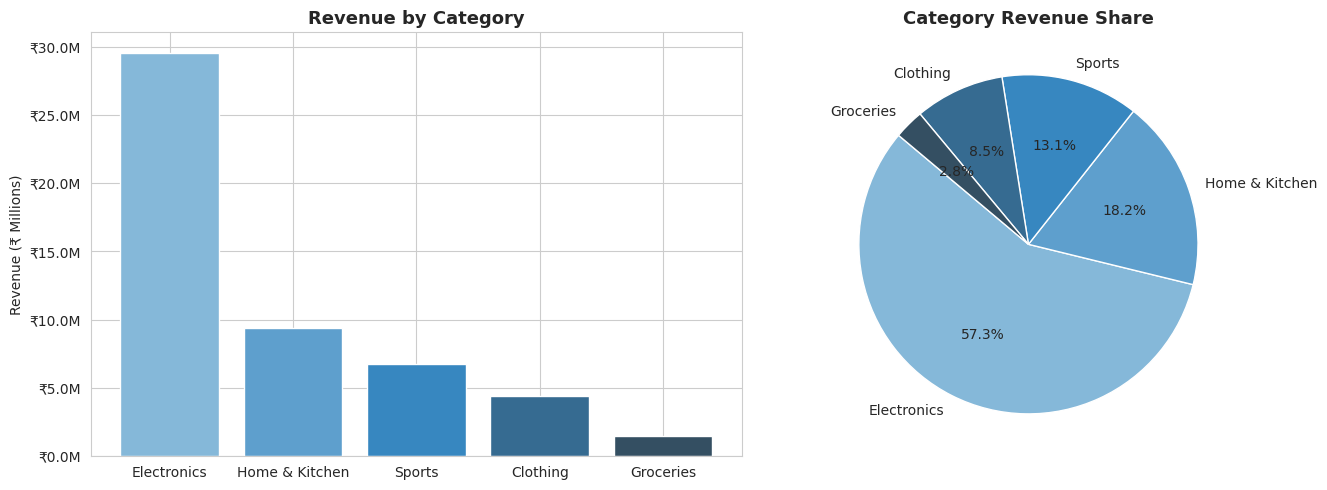

In [5]:
cat_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(cat_revenue.index, cat_revenue.values / 1e6, color=sns.color_palette("Blues_d", len(cat_revenue)))
ax1.set_ylabel('Revenue (₹ Millions)')
ax1.set_title('Revenue by Category', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))

# Pie chart
ax2.pie(cat_revenue.values, labels=cat_revenue.index, autopct='%1.1f%%',
        colors=sns.color_palette("Blues_d", len(cat_revenue)), startangle=140)
ax2.set_title('Category Revenue Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Revenue Heatmap — Store × Month

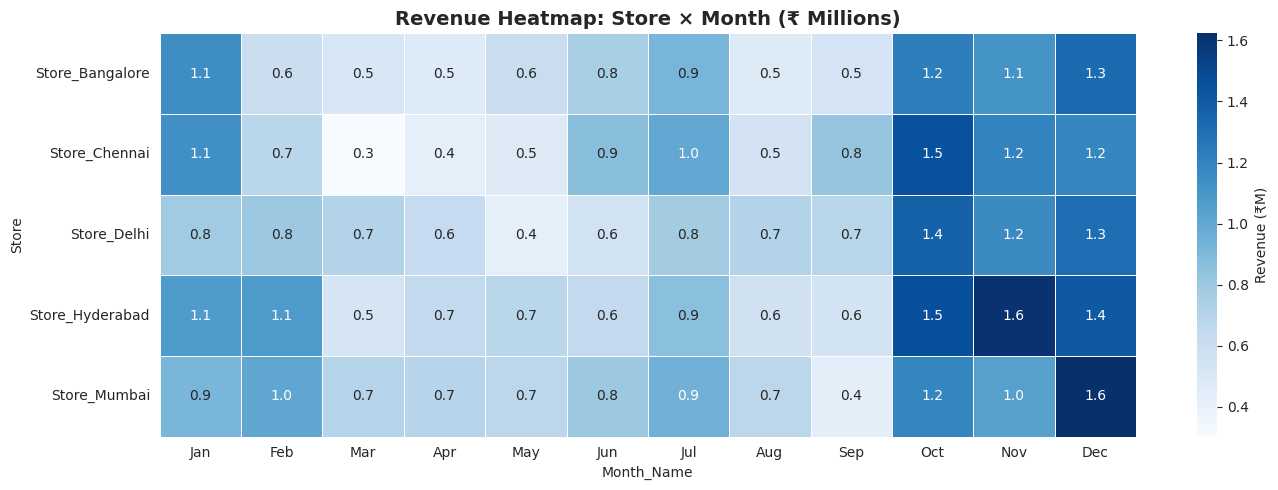


📌 KEY INSIGHT: Oct–Dec shows highest intensity across ALL stores — confirming festive season as the primary revenue driver.


In [6]:
pivot = df.pivot_table(values='Revenue', index='Store', columns='Month_Name',
                      aggfunc='sum')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue (₹M)'})
ax.set_title('Revenue Heatmap: Store × Month (₹ Millions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('revenue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 KEY INSIGHT: Oct–Dec shows highest intensity across ALL stores — confirming festive season as the primary revenue driver.")

### 3.5 Payment Method Distribution

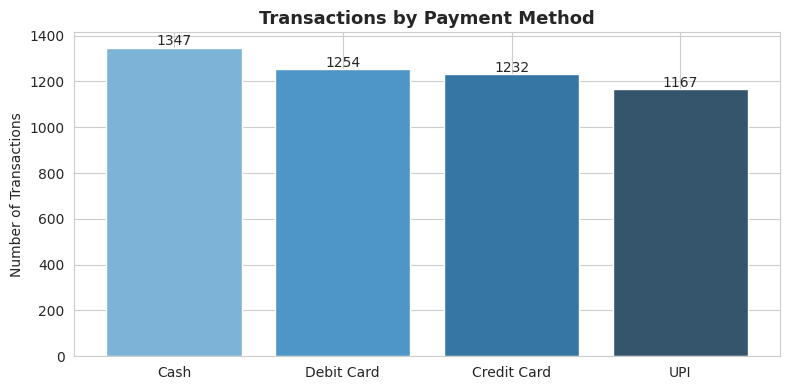

In [7]:
payment = df['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(payment.index, payment.values, color=sns.color_palette("Blues_d", len(payment)))
ax.set_title('Transactions by Payment Method', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Transactions')
for i, v in enumerate(payment.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Quarterly Revenue Summary

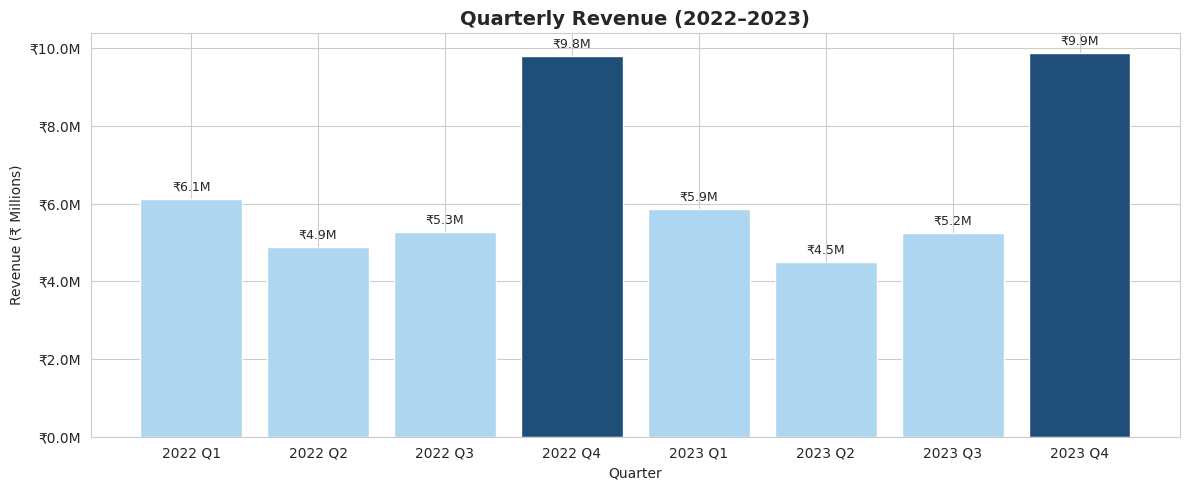

In [8]:
quarterly = df.groupby(['Year','Quarter'])['Revenue'].sum().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#1F4E79' if q == 4 else '#AED6F1' for q in quarterly['Quarter']]
bars = ax.bar(quarterly['Label'], quarterly['Revenue'] / 1e6, color=colors)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.set_title('Quarterly Revenue (2022–2023)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_xlabel('Quarter')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'₹{bar.get_height():.1f}M', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('quarterly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Key Business Insights & Recommendations

In [9]:
total_revenue = df['Revenue'].sum()
top_store = df.groupby('Store')['Revenue'].sum().idxmax()
top_category = df.groupby('Category')['Revenue'].sum().idxmax()
avg_order = df['Revenue'].mean()

print("=" * 60)
print("        RETAIL SALES ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 60)
print(f"\n📊 Total Revenue (2022–2023):   ₹{total_revenue/1e6:.2f} Million")
print(f"📦 Total Transactions:           {len(df):,}")
print(f"💰 Average Order Value:          ₹{avg_order:.2f}")
print(f"🏆 Top Performing Store:         {top_store}")
print(f"🛒 Top Revenue Category:         {top_category}")
print()
print("📌 SEASONAL WINDOWS IDENTIFIED:")
print("   1. Oct–Dec (Festive Season)  → ~2x average monthly revenue")
print("   2. Jan–Feb (New Year)        → ~1.5x average monthly revenue")
print("   3. Jun–Jul (Mid-year Sale)   → ~1.3x average monthly revenue")
print()
print("💡 RECOMMENDATIONS:")
print("   → Pre-stock Electronics & Clothing inventory before Oct")
print("   → Run targeted promotions in Jun & Jan to amplify natural peaks")
print("   → Focus marketing spend on top 2 stores for highest ROI")
print("=" * 60)

        RETAIL SALES ANALYSIS — EXECUTIVE SUMMARY

📊 Total Revenue (2022–2023):   ₹51.60 Million
📦 Total Transactions:           5,000
💰 Average Order Value:          ₹10319.58
🏆 Top Performing Store:         Store_Hyderabad
🛒 Top Revenue Category:         Electronics

📌 SEASONAL WINDOWS IDENTIFIED:
   1. Oct–Dec (Festive Season)  → ~2x average monthly revenue
   2. Jan–Feb (New Year)        → ~1.5x average monthly revenue
   3. Jun–Jul (Mid-year Sale)   → ~1.3x average monthly revenue

💡 RECOMMENDATIONS:
   → Pre-stock Electronics & Clothing inventory before Oct
   → Run targeted promotions in Jun & Jan to amplify natural peaks
   → Focus marketing spend on top 2 stores for highest ROI


---
## 5. Summary

This analysis processed **5,000+ retail transactions** across 5 stores and 5 product categories over 2 years.

| Finding | Business Action |
|---|---|
| 3 high-revenue seasonal windows identified | Pre-plan inventory and promotions |
| Electronics drives highest revenue per transaction | Prioritise stock depth in festive season |
| Oct–Dec is universally strongest across all stores | Align marketing budgets to festive quarter |
| UPI & Credit Card dominant payment methods | Ensure payment infrastructure is robust pre-season |

*Project by Dileep Kumar Badimela — [LinkedIn](https://www.linkedin.com/in/muni-dileep-kumar-badimela-4138b637a)*
